# 옥수수 수확량 예측 & 날씨 예측 — 처음부터 끝까지

이 노트북은 **ACDC(Agro-Climatic Data by County, 1981–2015)** 실데이터로
1) 옥수수 수확량을 예측하는 머신러닝, 2) 미래 날씨(기후) 자체를 예측하는 머신러닝
두 가지를 처음부터 끝까지 직접 만들면서 설명합니다. 코드를 함수 뒤에 숨기지 않고
**셀마다 실제로 무슨 계산을 하는지** 그대로 보여줍니다(블랙박스 없음).

**대상 데이터:** 옥수수·대두 주산지 12개 주(Corn Belt), 카운티×연도 패널.

**진행 순서**
1. 데이터 불러오기·병합
2. 피처 엔지니어링 (추세 vs 기상충격 분리)
3. EDA — 그림으로 데이터 이해하기
4. 머신러닝 1 — 수확량 예측 (여러 모델 비교)
5. 머신러닝 2 — 날씨(기후) 예측 (미래 날씨를 예측할 수 있는가?)
6. 결론 요약

## 1. 데이터 불러오기 및 병합

4개의 원본 CSV를 하나의 "카운티×연도" 표로 합칩니다.

| 파일 | 내용 | 조인 키 |
|---|---|---|
| `yielddata.csv` | 카운티별 옥수수·대두 수확량 (bu/ac) — **예측 타깃** | stco, year |
| `pptMarAug.csv` | 생육기(3~8월) 강수량 (mm) | stco, year |
| `gdd_slim.csv` | 온도 노출: gdd(유익열 10~29°C 합)·edd(유해 고온 30°C+ 합) | stco, year |
| `soil2011.csv` | 토양 특성(보수력·유기물·pH 등) — 카운티마다 거의 고정값 | stco |

`stco`는 미국 FIPS 코드(주+카운티)입니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 100, "font.size": 11, "axes.grid": True, "grid.alpha": 0.3})

DATA = "../data"

yield_df = pd.read_csv(f"{DATA}/yielddata.csv")
ppt_df   = pd.read_csv(f"{DATA}/pptMarAug.csv")
soil_df  = pd.read_csv(f"{DATA}/soil2011.csv")
temp_df  = pd.read_csv(f"{DATA}/gdd_slim.csv")

print("yield :", yield_df.shape)
print("ppt   :", ppt_df.shape)
print("soil  :", soil_df.shape)
print("temp  :", temp_df.shape)
yield_df.head()

yield : (107450, 6)
ppt   : (107450, 3)
soil  : (3070, 11)
temp  : (107320, 4)


,stco,year,corn,soybean,cotton,wheat
0,1001,1981,17.3,19.2,494.0,43.1
1,1003,1981,101.4,25.7,768.0,44.7
2,1005,1981,37.9,20.9,561.0,35.9
3,1007,1981,NaN,24.3,540.0,42.3
4,1009,1981,53.8,25.1,496.0,38.0


## 2. Corn Belt 12개 주로 좁히고 하나의 패널로 병합

미국 전역을 다 쓰면 옥수수를 거의 안 심는 카운티(뉴욕·네바다 등)가 결측·잡음으로 들어와
모델이 흐려집니다. 그래서 옥수수·대두 주산지 12개 주(Corn Belt)만 씁니다.

병합은 `stco`(+연도별 파일은 `year`도) 기준으로 왼쪽 조인(merge how='left')합니다.

In [2]:
CORN_BELT = {19: "IA", 17: "IL", 31: "NE", 27: "MN", 18: "IN", 20: "KS",
             39: "OH", 46: "SD", 29: "MO", 38: "ND", 55: "WI", 48: "TX"}


def build_panel(crop):
    """yield+ppt+temp+soil 을 병합하고, 결측 타깃 행은 제외한 최종 패널을 만든다."""
    d = (yield_df
         .merge(ppt_df, on=["stco", "year"], how="left")
         .merge(temp_df, on=["stco", "year"], how="left")
         .merge(soil_df, on="stco", how="left"))
    d["state"] = d["stco"] // 1000
    d["state_abbr"] = d["state"].map(CORN_BELT)
    d = d[d["state"].isin(CORN_BELT)].copy()
    need = [crop, "ppt", "edd", "whc", "om", "spH", "clay", "slope"]
    d = d.dropna(subset=need).copy()      # 타깃 결측 행은 대체하지 않고 제외
    return d


corn_raw = build_panel("corn")
soy_raw = build_panel("soybean")
print(f"옥수수 패널: {corn_raw.shape}  (카운티 {corn_raw.stco.nunique()}개)")
print(f"대두   패널: {soy_raw.shape}  (카운티 {soy_raw.stco.nunique()}개)")
corn_raw.head()

옥수수 패널: (34627, 21)  (카운티 1113개)
대두   패널: (29995, 21)  (카운티 1035개)


,stco,year,corn,soybean,cotton,wheat,ppt,gdd,edd,whc,sand,silt,clay,om,kwfactor,kffactor,spH,slope,tfactor,state,state_abbr
560,17001,1981,116.0,36.0,NaN,45.0,982.754034,144.9,9.3,34.816555,9.794088,62.058195,28.147717,153.843807,0.420090,0.420659,6.286546,100.573062,4.704058,17,IL
561,17003,1981,100.0,28.0,NaN,42.0,788.696235,137.3,26.8,31.641412,24.959399,47.958124,27.082477,174.459840,0.352644,0.354489,6.503335,47.045783,4.543438,17,IL
562,17005,1981,109.0,34.0,NaN,55.0,759.887082,140.3,18.1,26.118602,13.480414,58.099019,28.420567,103.892559,0.431482,0.431840,6.165360,58.583992,3.496400,17,IL
563,17007,1981,123.0,42.0,NaN,56.0,674.225498,136.9,4.0,26.875499,27.079088,48.488345,24.432567,258.016748,0.341668,0.343134,6.668108,85.552775,4.777542,17,IL
564,17009,1981,131.0,35.5,NaN,45.0,998.124938,144.6,9.2,31.537891,7.640115,63.688317,28.671568,124.558896,0.427200,0.427200,6.267097,107.878583,4.730802,17,IL


## 3. 피처 엔지니어링 — "기술추세"와 "기상충격" 분리

옥수수 수확량은 매년 품종·비료·농법이 좋아지면서 **꾸준히 오릅니다**(기술추세). 그 위에
그해 날씨가 좋으면 +, 가물면 - 로 출렁이는 게 **기상충격**입니다. 이 둘을 안 나누면
"연도가 클수록 수확량이 크다"만 배우고 정작 궁금한 기후 효과가 추세에 묻혀버립니다.

**방법:** 카운티마다 연도별 수확량에 선형추세선을 따로 적합합니다(카운티마다 토양 등
재배환경이 달라 절대 수확량이 다르므로, 각자의 추세선을 뽑아야 공정한 비교가 됩니다).

```
실제 수확량 = 그 카운티의 추세선(trend) + 기상충격(anomaly)
```

In [3]:
def add_trend_anomaly(data, crop):
    """카운티별 선형추세를 적합해 trend/anom/anom_pct 세 컬럼을 추가한다."""
    data = data.sort_values(["stco", "year"]).copy()
    trend = np.full(len(data), np.nan)
    for stco, idx in data.groupby("stco").groups.items():
        sub = data.loc[idx, ["year", crop]].dropna()
        if len(sub) >= 5:                          # 추세를 뽑으려면 최소 5개년
            b1, b0 = np.polyfit(sub.year, sub[crop], 1)
            trend[data.index.get_indexer(idx)] = b0 + b1 * data.loc[idx, "year"]
    data[f"{crop}_trend"] = trend
    data[f"{crop}_anom"] = data[crop] - data[f"{crop}_trend"]
    data[f"{crop}_anom_pct"] = 100 * data[f"{crop}_anom"] / data[f"{crop}_trend"]
    return data


corn = add_trend_anomaly(corn_raw, "corn")
soy = add_trend_anomaly(soy_raw, "soybean")
corn[["stco", "year", "corn", "corn_trend", "corn_anom"]].head()

,stco,year,corn,corn_trend,corn_anom
560,17001,1981,116.0,104.129524,11.870476
3630,17001,1982,124.0,105.848796,18.151204
6700,17001,1983,46.0,107.568067,-61.568067
9770,17001,1984,103.0,109.287339,-6.287339
12840,17001,1985,136.0,111.006611,24.993389


## 4. EDA — 그림으로 데이터 이해하기

이제 데이터가 실제로 무슨 이야기를 하는지 그림 5장으로 확인합니다.

### 그림 1. 수확량 = 기술추세 + 기상충격

전국(Corn Belt) 평균 실제 수확량(파란 선)과 추세선(회색 점선)을 겹쳐 그립니다.
1983·1988·1993·2012년처럼 크게 처지는 해가 그해의 '기상충격'(가뭄·홍수)입니다.

기술추세: 연평균 +1.7 bu/ac 상승
2012 실제 109 vs 추세기대 143 bu/ac


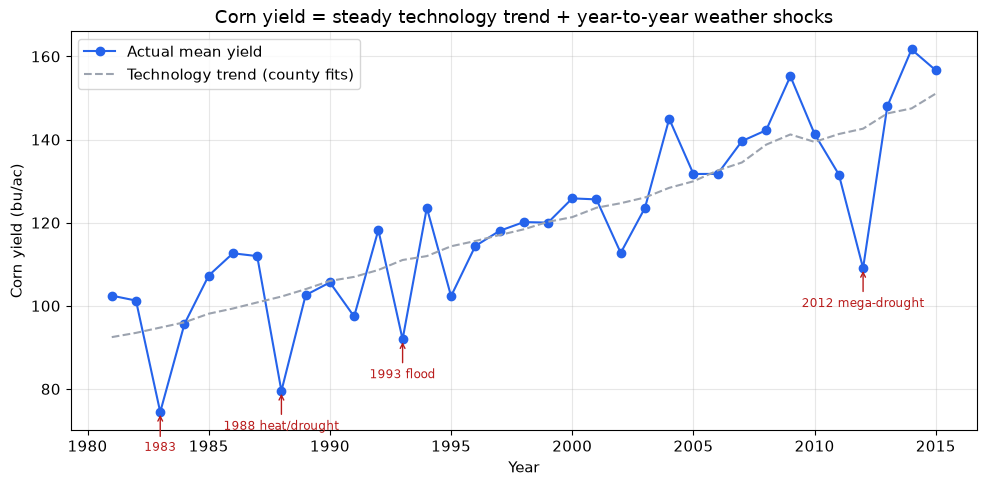

In [4]:
nat = corn.groupby("year").agg(yield_mean=("corn", "mean"),
                               trend_mean=("corn_trend", "mean")).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(nat.year, nat.yield_mean, "o-", color="#2563eb", label="Actual mean yield")
ax.plot(nat.year, nat.trend_mean, "--", color="#9ca3af", label="Technology trend (county fits)")

droughts = {1983: "1983", 1988: "1988 heat/drought", 1993: "1993 flood", 2012: "2012 mega-drought"}
for yr, lab in droughts.items():
    if yr in nat.year.values:
        v = nat.loc[nat.year == yr, "yield_mean"].iloc[0]
        ax.annotate(lab, (yr, v), textcoords="offset points", xytext=(0, -28), ha="center",
                    fontsize=8.5, color="#b91c1c",
                    arrowprops=dict(arrowstyle="->", color="#b91c1c", lw=1))

ax.set(xlabel="Year", ylabel="Corn yield (bu/ac)",
       title="Corn yield = steady technology trend + year-to-year weather shocks")
ax.legend()
plt.tight_layout()
plt.show()

tech_gain = (nat.trend_mean.iloc[-1] - nat.trend_mean.iloc[0]) / (nat.year.iloc[-1] - nat.year.iloc[0])
print(f"기술추세: 연평균 +{tech_gain:.1f} bu/ac 상승")
print(f"2012 실제 {nat.loc[nat.year==2012,'yield_mean'].iloc[0]:.0f} vs "
      f"추세기대 {nat.loc[nat.year==2012,'trend_mean'].iloc[0]:.0f} bu/ac")

### 그림 2. 강수 반응은 '언덕형' — 최적점이 있다

추세를 제거한 순수 '기상충격'을 강수 구간별로 평균 내 봅니다. 직선이 아니라
**∩ 모양**이 나옵니다: 비가 너무 적어도(가뭄), 너무 많아도(침수·일조부족) 둘 다
수확량을 깎습니다. → 이게 뒤에서 **선형 모델이 아니라 트리 모델**을 써야 하는 이유입니다.

수확량이 최대가 되는 강수 구간: 약 838mm 부근


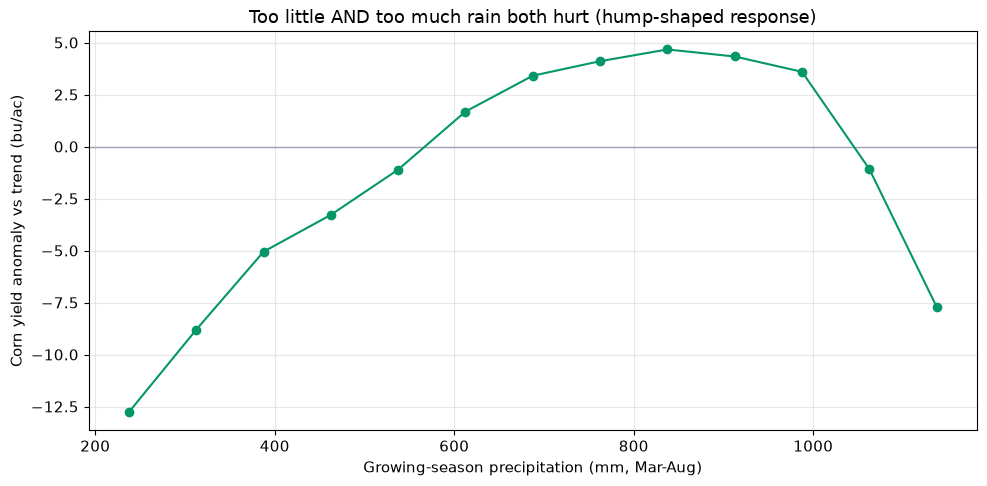

In [5]:
d = corn.dropna(subset=["corn_anom", "ppt"]).copy()
d["ppt_bin"] = pd.cut(d.ppt, bins=np.arange(200, 1200, 75))
g = d.groupby("ppt_bin", observed=True).agg(anom=("corn_anom", "mean"),
                                            n=("corn_anom", "size")).reset_index()
g = g[g.n >= 50]
centers = g.ppt_bin.apply(lambda b: b.mid).astype(float)

fig, ax = plt.subplots(figsize=(10, 5))
ax.axhline(0, color="#9ca3af", lw=1)
ax.plot(centers, g.anom, "o-", color="#059669")
ax.set(xlabel="Growing-season precipitation (mm, Mar-Aug)",
       ylabel="Corn yield anomaly vs trend (bu/ac)",
       title="Too little AND too much rain both hurt (hump-shaped response)")
plt.tight_layout()
plt.show()

peak = g.loc[g.anom.idxmax(), "ppt_bin"].mid
print(f"수확량이 최대가 되는 강수 구간: 약 {peak:.0f}mm 부근")

### 그림 3. 어느 주가 날씨에 가장 흔들리나 — 기후 취약도

기상충격(추세 대비 %)의 **표준편차**가 큰 주 = 날씨에 따라 수확량이 크게 출렁이는 주입니다.

변동성 최대: SD (37.8%)  |  최소: NE (12.9%)
→ 원인은 이 데이터로 확인할 수 없습니다(관개 등 원인 후보 컬럼이 데이터에 없음).
  '어디가 위험한가'라는 관측 사실만 사용하고, 원인 규명은 실제 관개 데이터 확보 후 과제로 남깁니다.


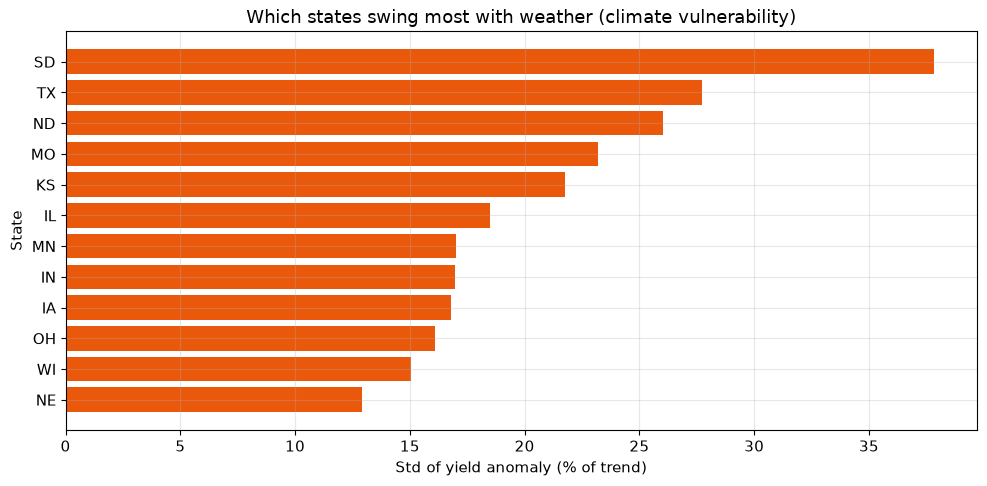

In [6]:
g = corn.dropna(subset=["corn_anom_pct"]).groupby("state_abbr").corn_anom_pct.std().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(g.index, g.values, color="#ea580c")
ax.set(xlabel="Std of yield anomaly (% of trend)", ylabel="State",
       title="Which states swing most with weather (climate vulnerability)")
plt.tight_layout()
plt.show()

print(f"변동성 최대: {g.index[-1]} ({g.iloc[-1]:.1f}%)  |  최소: {g.index[0]} ({g.iloc[0]:.1f}%)")
print("→ 원인은 이 데이터로 확인할 수 없습니다(관개 등 원인 후보 컬럼이 데이터에 없음).")
print("  '어디가 위험한가'라는 관측 사실만 사용하고, 원인 규명은 실제 관개 데이터 확보 후 과제로 남깁니다.")

### 그림 4. 극한고온(EDD) 타임라인 — 고온해가 흉작과 정렬하는가

`edd`는 30°C를 넘는 고온에 노출된 정도(유해 고온 노출량)입니다. 연도별 EDD(막대)와
옥수수 수확량 편차(선)를 겹쳐서, 고온해가 실제로 흉작해와 맞아떨어지는지 봅니다.

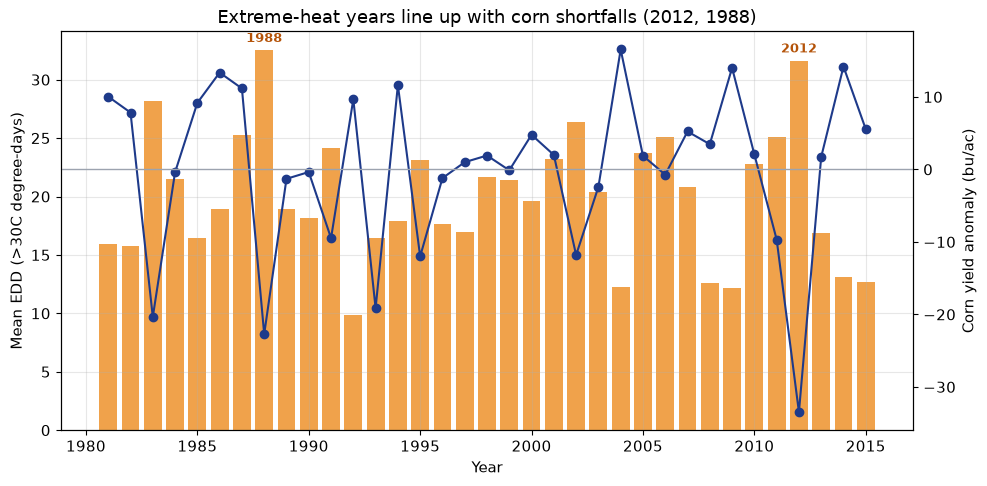

In [7]:
g = corn.groupby("year").agg(edd=("edd", "mean"), corn_anom=("corn_anom", "mean")).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(g.year, g.edd, color="#f0a24b", label="EDD (extreme heat)")
ax1.set(xlabel="Year", ylabel="Mean EDD (>30C degree-days)")

ax2 = ax1.twinx()
ax2.plot(g.year, g.corn_anom, "o-", color="#1e3a8a", label="Corn yield anomaly")
ax2.axhline(0, color="#9ca3af", lw=1)
ax2.set_ylabel("Corn yield anomaly (bu/ac)")
ax2.grid(False)

for yr in (1988, 2012):
    if yr in g.year.values:
        ax1.annotate(str(yr), (yr, g.loc[g.year == yr, "edd"].iloc[0]),
                     textcoords="offset points", xytext=(0, 6), ha="center",
                     fontsize=9, color="#b45309", fontweight="bold")

ax1.set_title("Extreme-heat years line up with corn shortfalls (2012, 1988)")
plt.tight_layout()
plt.show()

### 그림 5. 옥수수 vs 대두 — 누가 고온에 더 약한가

같은 정도의 극한고온(EDD)에서 옥수수와 대두의 수확량 편차(%)를 나란히 그립니다.

→ 같은 고온 노출에서 옥수수(주황)의 하락 기울기가 대두(초록)보다 가파릅니다.
  이게 2012년에 옥수수만 크게 무너지고 대두는 상대적으로 버틴 이유입니다.


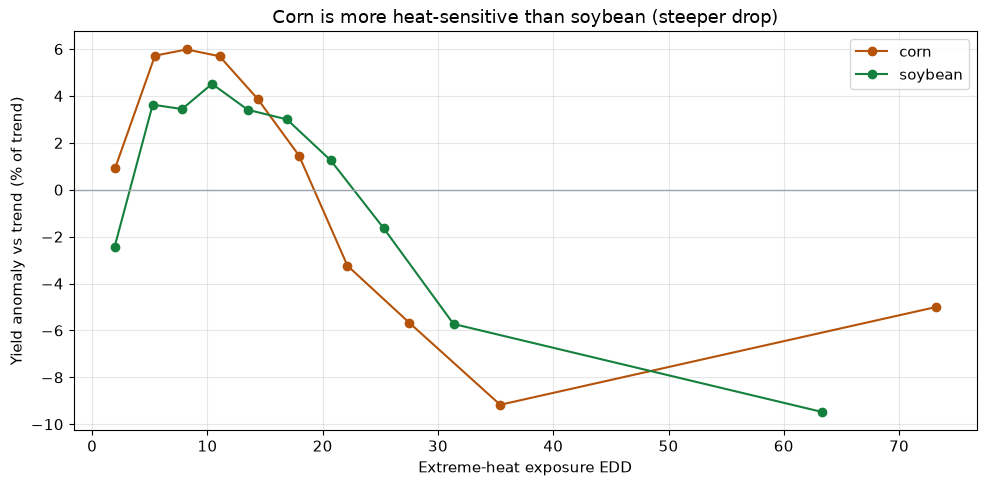

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
for data, crop, color in [(corn, "corn", "#b45309"), (soy, "soybean", "#15803d")]:
    col = f"{crop}_anom_pct"
    dd = data.dropna(subset=[col, "edd"]).copy()
    dd["edd_bin"] = pd.qcut(dd.edd, 10, duplicates="drop")
    gg = dd.groupby("edd_bin", observed=True)[col].mean()
    centers = [b.mid for b in gg.index]
    ax.plot(centers, gg.values, "o-", color=color, label=crop)

ax.axhline(0, color="#9ca3af", lw=1)
ax.set(xlabel="Extreme-heat exposure EDD", ylabel="Yield anomaly vs trend (% of trend)",
       title="Corn is more heat-sensitive than soybean (steeper drop)")
ax.legend()
plt.tight_layout()
plt.show()

print("→ 같은 고온 노출에서 옥수수(주황)의 하락 기울기가 대두(초록)보다 가파릅니다.")
print("  이게 2012년에 옥수수만 크게 무너지고 대두는 상대적으로 버틴 이유입니다.")

## 5. 머신러닝 1 — 수확량 예측 모델 비교

이제 실제로 모델을 학습시킵니다. **왜 트리 모델(RandomForest·Gradient Boosting)을
쓰는지**를 그냥 주장하지 않고, 선형 모델(OLS·Ridge·Lasso)과 나란히 비교해서
데이터로 보여줍니다.

**시간 분할:** 2010년 이전 데이터로 학습하고 2011~2015년으로 평가합니다. 무작위로
섞어서 나누면(랜덤 분할) 미래 정보가 학습에 새어 들어가므로(데이터 누수), 실제
예보 상황처럼 **미래를 미리 보지 않게** 연도 기준으로 나눕니다.

In [9]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SPLIT_YEAR = 2011
corn_ml = corn.copy()
corn_ml["ppt2"] = corn_ml["ppt"] ** 2                      # 강수의 언덕형(비선형) 반응을 선형모델도 일부 잡게
NUM = ["gdd", "edd", "ppt", "ppt2", "whc", "om", "spH", "clay", "slope", "year"]

train = corn_ml[corn_ml.year < SPLIT_YEAR]
test = corn_ml[corn_ml.year >= SPLIT_YEAR]
print(f"학습 {len(train):,}행 (~{SPLIT_YEAR-1}) / 테스트 {len(test):,}행 ({SPLIT_YEAR}~2015)")

학습 30,303행 (~2010) / 테스트 4,324행 (2011~2015)


### 5.1 다섯 개 모델을 같은 조건으로 학습

| 모델 | 배우는 관계 |
|---|---|
| OLS | 순수 직선 |
| Ridge | 직선 + 계수를 작게 누르는 규제(L2) — 변수끼리 겹칠 때(다중공선성) 안정적 |
| Lasso | 직선 + 일부 계수를 아예 0으로 만드는 규제(L1) — 자동 변수선택 |
| RandomForest | 여러 결정트리의 평균 — 비선형·구간별 관계를 자동으로 잡음 |
| Gradient Boosting (GBM) | 트리를 순차적으로 오차 보정하며 쌓음 — 보통 가장 정확 |

선형 계열은 표준화 후 학습, 트리 계열은 원본 그대로 학습합니다(트리는 스케일에 영향 안 받음).

In [10]:
def make_pipeline(model, linear):
    if linear:
        pre = ColumnTransformer([("num", StandardScaler(), NUM),
                                 ("cat", OneHotEncoder(handle_unknown="ignore"), ["state"])])
    else:
        pre = ColumnTransformer([("num", "passthrough", NUM),
                                 ("cat", "passthrough", ["state"])])
    return Pipeline([("pre", pre), ("model", model)])


models = {
    "OLS":          make_pipeline(LinearRegression(), True),
    "Ridge":        make_pipeline(Ridge(alpha=10.0), True),
    "Lasso":        make_pipeline(Lasso(alpha=0.5, max_iter=5000), True),
    "RandomForest": make_pipeline(RandomForestRegressor(n_estimators=300, min_samples_leaf=3,
                                                        n_jobs=-1, random_state=0), False),
    "GBM":          make_pipeline(HistGradientBoostingRegressor(max_iter=400, learning_rate=0.05,
                                                                 max_leaf_nodes=31, random_state=0), False),
}

X_cols = NUM + ["state"]
results = []
fitted = {}
for name, pipe in models.items():
    pipe.fit(train[X_cols], train["corn"])
    pred = pipe.predict(test[X_cols])
    results.append({"model": name,
                    "RMSE": np.sqrt(mean_squared_error(test["corn"], pred)),
                    "MAE": mean_absolute_error(test["corn"], pred),
                    "R2": r2_score(test["corn"], pred)})
    fitted[name] = pipe

res_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
res_df.round(2)

,model,RMSE,MAE,R2
0,GBM,27.19,20.88,0.58
1,RandomForest,27.62,20.91,0.56
2,OLS,31.30,24.19,0.44
3,Ridge,31.34,24.22,0.44
4,Lasso,33.10,26.01,0.37


RMSE(평균 오차, 낮을수록 좋음)와 R²(설명력, 1에 가까울수록 좋음)를 막대그래프로 봅니다.

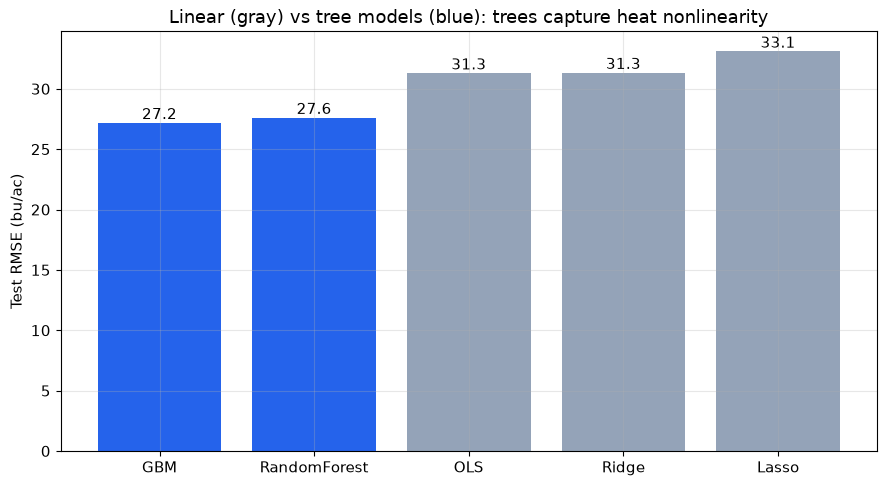

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#94a3b8" if m in ("OLS", "Ridge", "Lasso") else "#2563eb" for m in res_df.model]
ax.bar(res_df.model, res_df.RMSE, color=colors)
for i, v in enumerate(res_df.RMSE):
    ax.text(i, v, f"{v:.1f}", ha="center", va="bottom")
ax.set(ylabel="Test RMSE (bu/ac)", title="Linear (gray) vs tree models (blue): trees capture heat nonlinearity")
plt.tight_layout()
plt.show()

### 5.2 왜 트리가 이기나 — 유해고온 반응 곡선으로 확인

다른 변수는 중간값으로 고정하고 `edd`(유해 고온)만 움직여 각 모델이 예측하는 수확량이
어떻게 변하는지 그려봅니다(부분의존도, partial dependence).

→ Ridge(회색)는 직선 하나뿐이라 '고온이 심해질수록 손해가 급격히 커지는' 모양을 못 그립니다.
  GBM(빨강)은 꺾이는 지점을 그대로 재현합니다 — 이게 트리 모델이 이기는 이유입니다.


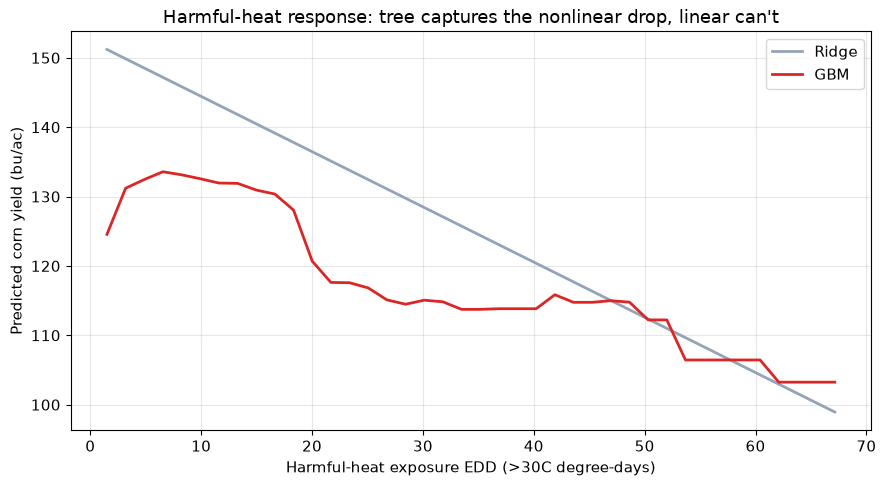

In [12]:
med = {c: corn_ml[c].median() for c in NUM}
grid = np.linspace(corn_ml.edd.quantile(.02), corn_ml.edd.quantile(.98), 40)
base_row = pd.DataFrame({**{c: med[c] for c in NUM}, "state": corn_ml.state.mode()[0]},
                        index=range(len(grid)))
base_row["edd"] = grid

fig, ax = plt.subplots(figsize=(9, 5))
for name, color in [("Ridge", "#94a3b8"), ("GBM", "#dc2626")]:
    ax.plot(grid, fitted[name].predict(base_row[X_cols]), color=color, label=name, lw=2)
ax.set(xlabel="Harmful-heat exposure EDD (>30C degree-days)", ylabel="Predicted corn yield (bu/ac)",
       title="Harmful-heat response: tree captures the nonlinear drop, linear can't")
ax.legend()
plt.tight_layout()
plt.show()

print("→ Ridge(회색)는 직선 하나뿐이라 '고온이 심해질수록 손해가 급격히 커지는' 모양을 못 그립니다.")
print("  GBM(빨강)은 꺾이는 지점을 그대로 재현합니다 — 이게 트리 모델이 이기는 이유입니다.")

### 5.3 순열 중요도 — 모델이 무엇을 근거로 예측하나 (블랙박스 열기)

가장 성능이 좋은 모델에서, 피처 하나씩을 무작위로 뒤섞었을 때 예측력(R²)이 얼마나
떨어지는지를 봅니다. 많이 떨어질수록 그 피처가 중요하다는 뜻입니다.

최고 모델: GBM
중요도 top3:
edd    0.257
whc    0.110
gdd    0.105
dtype: float64


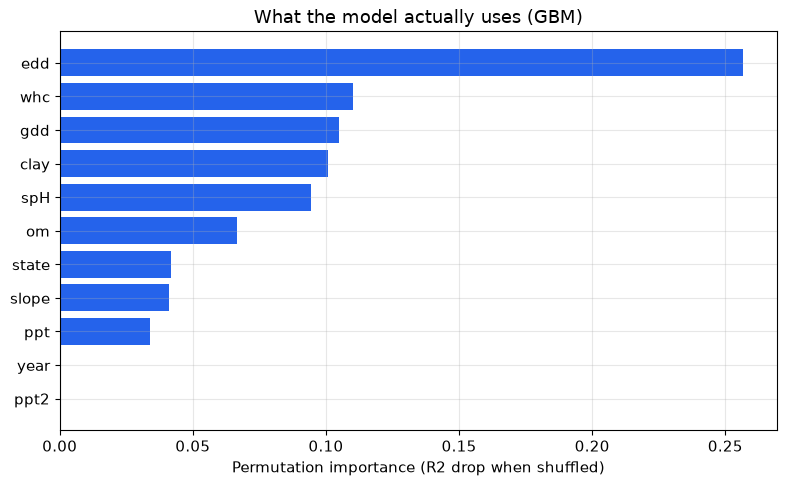

In [13]:
from sklearn.inspection import permutation_importance

best_name = res_df.iloc[0]["model"]
best_model = fitted[best_name]
pi = permutation_importance(best_model, test[X_cols], test["corn"], n_repeats=10,
                            random_state=0, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=X_cols).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp.index, imp.values, color="#2563eb")
ax.set(xlabel="Permutation importance (R2 drop when shuffled)",
       title=f"What the model actually uses ({best_name})")
plt.tight_layout()
plt.show()

print(f"최고 모델: {best_name}")
print("중요도 top3:")
print(imp.sort_values(ascending=False).head(3).round(3))

### 5.4 2012년 대가뭄 스트레스 테스트 — 데이터 적합성의 정직한 판정

모델이 최악의 해(2012년 미국 대가뭄)를 얼마나 잘 맞히는지가 이 모델의 진짜 한계를
보여줍니다. 평균 R²만 보면 놓치는 부분입니다.

In [14]:
mask2012 = (test.year == 2012).values
pred_best = best_model.predict(test[X_cols])

actual_2012 = test.loc[mask2012, "corn"].mean()
pred_2012 = pred_best[mask2012].mean()

print(f"2012 실제 평균 수확량: {actual_2012:.1f} bu/ac")
print(f"2012 모델 예측 평균:   {pred_2012:.1f} bu/ac")
print(f"오차: {pred_2012 - actual_2012:+.1f} bu/ac  "
      f"({'과대예측(가뭄 과소평가)' if pred_2012 > actual_2012 else '과소예측'})")
print()
print("→ 2012년은 강수 부족 + 개화기(7월) 극한고온이 겹친 사건인데, 우리 피처는")
print("  3~8월 '계절 총합'이라 7월 한 달의 집중 피해가 희석됩니다. 그래서 모델이")
print("  이 정도로 나쁠 줄은 과소평가합니다 — '평년엔 쓸만하지만 극단적 해는 어렵다'는")
print("  이 데이터의 정직한 한계입니다.")

2012 실제 평균 수확량: 109.1 bu/ac
2012 모델 예측 평균:   137.8 bu/ac
오차: +28.8 bu/ac  (과대예측(가뭄 과소평가))

→ 2012년은 강수 부족 + 개화기(7월) 극한고온이 겹친 사건인데, 우리 피처는
  3~8월 '계절 총합'이라 7월 한 달의 집중 피해가 희석됩니다. 그래서 모델이
  이 정도로 나쁠 줄은 과소평가합니다 — '평년엔 쓸만하지만 극단적 해는 어렵다'는
  이 데이터의 정직한 한계입니다.


## 6. 머신러닝 2 — 날씨(기후) 예측: 미래 날씨를 예측할 수 있는가?

지금까지는 "올해 날씨가 주어졌을 때 수확량"을 예측했습니다. 이번엔 거꾸로,
**"미래의 날씨(고온 노출·강수) 자체를 예측할 수 있는가"**를 봅니다. 온난화 시나리오를
만들려면 이게 먼저 필요하기 때문입니다.

### 6.1 분산 분해 — 날씨 변동은 '어디(공간)' 때문인가 '언제(시간)' 때문인가

같은 카운티는 해마다 비슷한 기후를 갖는 경향이 있고(따뜻한 남부 vs 서늘한 북부),
그 위에 그해만의 변동이 더해집니다. 전체 분산을 "카운티 간 차이(공간)"와
"연도 간 차이(시간)"로 나눠봅니다.

In [15]:
def var_decomp(data, col):
    grand = data[col].mean()
    cty = data.groupby("stco")[col].transform("mean")
    yr = data.groupby("year")[col].transform("mean")
    ss_tot = ((data[col] - grand) ** 2).sum()
    ss_space = ((cty - grand) ** 2).sum()
    ss_time = ((yr - grand) ** 2).sum()
    return ss_space / ss_tot, ss_time / ss_tot


rows = []
for c in ["edd", "gdd", "ppt"]:
    s, t = var_decomp(corn, c)
    rows.append((c, s, t, 1 - s - t))
dec = pd.DataFrame(rows, columns=["variable", "space_%", "time_%", "residual_%"])
dec[["space_%", "time_%", "residual_%"]] = (dec[["space_%", "time_%", "residual_%"]] * 100).round(1)
dec

,variable,space_%,time_%,residual_%
0,edd,82.9,11.0,6.1
1,gdd,38.8,39.4,21.8
2,ppt,40.3,19.0,40.7


→ EDD(극한고온) 변동의 대부분은 '어느 카운티냐'로 설명됩니다. '어느 해냐'는 훨씬 작습니다.


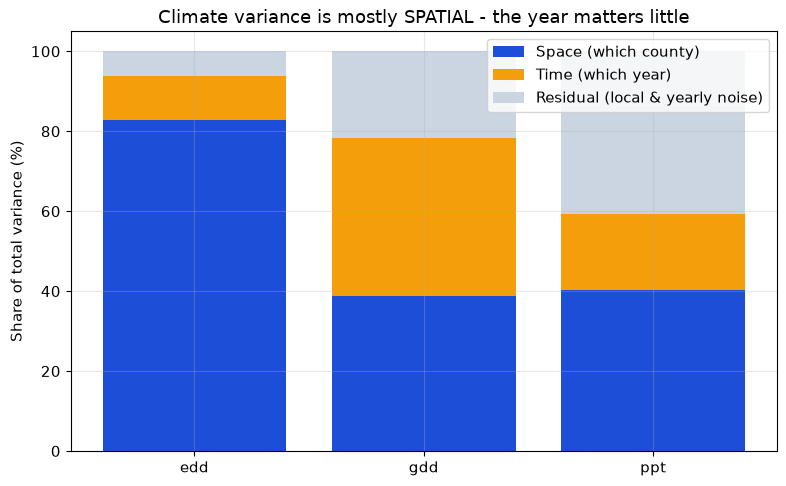

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(dec.variable, dec["space_%"], label="Space (which county)", color="#1d4ed8")
ax.bar(dec.variable, dec["time_%"], bottom=dec["space_%"], label="Time (which year)", color="#f59e0b")
ax.bar(dec.variable, dec["residual_%"], bottom=dec["space_%"] + dec["time_%"],
       label="Residual (local & yearly noise)", color="#cbd5e1")
ax.set(ylabel="Share of total variance (%)",
       title="Climate variance is mostly SPATIAL - the year matters little")
ax.legend()
plt.tight_layout()
plt.show()

print("→ EDD(극한고온) 변동의 대부분은 '어느 카운티냐'로 설명됩니다. '어느 해냐'는 훨씬 작습니다.")

### 6.2 자기상관 — 작년 날씨로 올해를 맞힐 수 있나

작년 값과 올해 값의 상관관계(lag-1 자기상관)를 봅니다. 1에 가까우면 "작년이 더우면
올해도 덥다"는 예측력이 있다는 뜻이고, 0에 가까우면 예측력이 없다는 뜻입니다.

edd: 작년→올해 상관계수 0.111
gdd: 작년→올해 상관계수 0.022
ppt: 작년→올해 상관계수 0.015


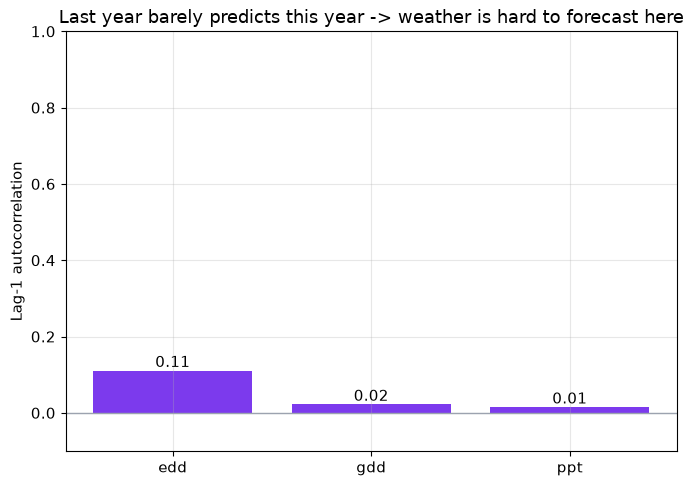

In [17]:
autocorr = {}
for c in ["edd", "gdd", "ppt"]:
    piv = corn.pivot_table(index="year", columns="stco", values=c)
    autocorr[c] = piv.corrwith(piv.shift(1)).mean()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(list(autocorr.keys()), list(autocorr.values()), color="#7c3aed")
for i, v in enumerate(autocorr.values()):
    ax.text(i, v, f"{v:.2f}", ha="center", va="bottom")
ax.axhline(0, color="#9ca3af", lw=1)
ax.set_ylim(-0.1, 1)
ax.set(ylabel="Lag-1 autocorrelation",
       title="Last year barely predicts this year -> weather is hard to forecast here")
plt.tight_layout()
plt.show()

for c, v in autocorr.items():
    print(f"{c}: 작년→올해 상관계수 {v:.3f}")

### 6.3 진짜 승부 — ML이 '단순히 카운티 평년값을 아는 것'보다 나은가

이제 미래 EDD를 예측하는 모델을 학습시키고, 두 가지 단순한 베이스라인과 비교합니다.

- **Climatology (평년)**: 그 카운티의 과거 평균값을 그대로 씀 (공간만 아는 모델)
- **Persistence (작년값)**: 작년 값을 그대로 올해 예측으로 씀

ML이 이 단순한 두 방법을 못 이기면, "미래 날씨를 예측할 수 있다"고 말할 수 없습니다.

In [18]:
def add_lag(data, col):
    data = data.sort_values(["stco", "year"]).copy()
    data[f"{col}_lag1"] = data.groupby("stco")[col].shift(1)
    return data


target = "edd"
wdf = add_lag(corn, target).dropna(subset=[f"{target}_lag1"])
wfeats = ["year", "state", "whc", "om", "spH", "clay", "slope", f"{target}_lag1"]
wtrain, wtest = wdf[wdf.year < SPLIT_YEAR], wdf[wdf.year >= SPLIT_YEAR]

wm = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_leaf_nodes=31, random_state=0)
wm.fit(wtrain[wfeats], wtrain[target])
wpred = wm.predict(wtest[wfeats])

clim = wtrain.groupby("stco")[target].mean()
base_clim = wtest["stco"].map(clim).fillna(wtrain[target].mean()).values
base_persist = wtest[f"{target}_lag1"].values

r2_ml = r2_score(wtest[target], wpred)
r2_clim = r2_score(wtest[target], base_clim)
r2_persist = r2_score(wtest[target], base_persist)

print("[절대값 예측 R²] (높을수록 좋음)")
print(f"  ML          : {r2_ml:.2f}")
print(f"  Climatology : {r2_clim:.2f}")
print(f"  Persistence : {r2_persist:.2f}")

# 연차편차(카운티 평년을 뺀 '그해만의 변동') 예측력 — 진짜 승부처
anom_true = wtest[target].values - base_clim
anom_pred = wpred - base_clim
r2_anom = r2_score(anom_true, anom_pred)
print(f"\n[연차편차 R²] (평년을 뺀 후에도 ML이 맞히는가): {r2_anom:.2f}")

[절대값 예측 R²] (높을수록 좋음)
  ML          : 0.56
  Climatology : 0.75
  Persistence : 0.70

[연차편차 R²] (평년을 뺀 후에도 ML이 맞히는가): -0.76


→ 단순 '카운티 평년값(Climatology)'이 ML보다 낫습니다.
  즉 ML이 배우는 건 대부분 '어느 카운티가 원래 더운가'이지, '올해가 특별히 더울 것'을
  맞히는 능력이 아닙니다.


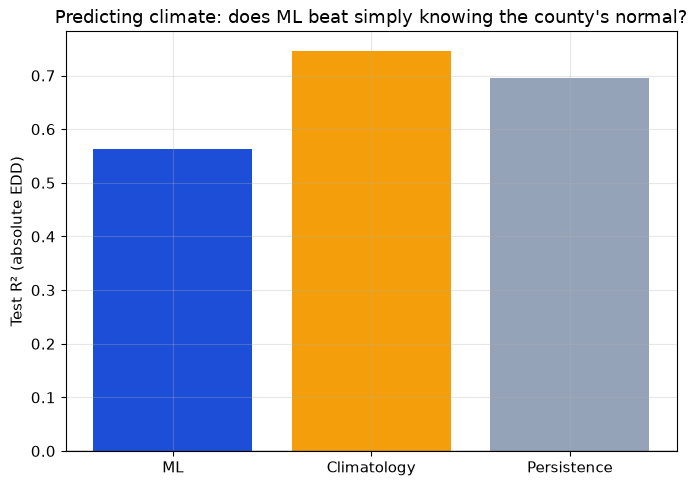

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
methods = ["ML", "Climatology", "Persistence"]
values = [r2_ml, r2_clim, r2_persist]
colors = ["#1d4ed8", "#f59e0b", "#94a3b8"]
ax.bar(methods, values, color=colors)
ax.axhline(0, color="#444", lw=1)
ax.set(ylabel="Test R² (absolute EDD)",
       title="Predicting climate: does ML beat simply knowing the county's normal?")
plt.tight_layout()
plt.show()

if r2_clim > r2_ml:
    print("→ 단순 '카운티 평년값(Climatology)'이 ML보다 낫습니다.")
    print("  즉 ML이 배우는 건 대부분 '어느 카운티가 원래 더운가'이지, '올해가 특별히 더울 것'을")
    print("  맞히는 능력이 아닙니다.")

### 6.4 결론 — 미래 날씨는 "예측"이 아니라 "시나리오"로 다뤄야 한다

위 결과를 종합하면:

1. 극한고온(EDD) 변동의 **대부분(약 80%)이 공간적**(어느 카운티냐)이고 시간적 변동은 작다.
2. 작년 날씨로 올해를 맞히는 자기상관이 **거의 0**에 가깝다.
3. 미래 EDD를 예측하는 ML이 **단순 평년값보다도 못하다.**

→ 세 가지 증거가 같은 결론을 가리킵니다: **연차 단위의 날씨는 데이터에서 배워 예측할
수 있는 대상이 아닙니다.** 그래서 "온난화 상황"을 다룰 때는 ML이 뽑아낸 미래 예측치를
쓰는 대신, **IPCC 같은 외부 기후과학 지식을 명시적 가정(시나리오)으로 부과**하고,
"이 가정이 맞다면 수확량이 이렇게 변한다"는 방식으로 분석해야 합니다.

## 7. 전체 요약

| 트랙 | 핵심 결과 |
|---|---|
| **수확량 예측** | GBM이 가장 정확(선형모델보다 우수) — 이유는 유해고온의 비선형 반응을 잡아내기 때문. 순열 중요도에서 극한고온(edd)이 최상위 피처. 다만 2012 같은 극단해는 계절 총합 피처의 한계로 과소평가됨. |
| **날씨 예측** | 연차 단위 날씨(그 해가 평년보다 더울지)는 ML로도 거의 예측 불가 — 카운티 평년값을 아는 것과 큰 차이가 없음. 따라서 온난화는 예측이 아니라 외생 시나리오로 다뤄야 함. |

**다음 단계로 이어지는 것:** 이 노트북에서 학습한 수확량 예측 모델의 예측값(Ŷ)이,
카운티별 작물 배치를 최적화하는 2단계(LP/조합최적화)의 입력으로 그대로 들어갑니다
(Predict-then-Optimize). 최적화 코드는 `acdc/src/optimizer.py`,
`acdc/src/optimize_meta.py`에 있습니다.